In [1]:
%load_ext autoreload
%autoreload 2

In [37]:
import importlib 
m = importlib.import_module(".model", "src")
em = importlib.import_module(".em", "src")
from matplotlib import pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import numpy as np
import xgi
import copy
import random
import statistics
import matplotlib.pyplot as plt
import scipy.special as ss

def plot_AUC(y_pred, y_true, plot_name):
    
    fpr, tpr, _ = roc_curve(y_true,y_pred)
    roc_auc = auc(fpr, tpr)
    plt.clf()
    plt.figure()
    lw = 2
    plt.plot(fpr, tpr, color='darkorange',
             lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curve ' + plot_name + " (first 1000 edges)")
    plt.legend(loc="lower right")
    
    plt.savefig(f"figures/ROC-{plot_name}.png", dpi = 300, bbox_inches = "tight")
    plt.show()

def plot_PR(y_pred, y_true, plot_name):

    precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
    plt.plot(recall, precision, marker='.', label='PR curve')
    # axis labels
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    # show the legend
    plt.legend()
    plt.title('Precision Recall '+plot_name)
    plt.savefig("Host-unipartite-PR.pdf", bbox_inches='tight')


# estimator likelihood definitions
# pmfs are used in E-step
# m_step estimators are the parameter estimators for each distribution
# used in m-step, using the matrix chi formed in the E-step

# edge sampling
def edge_sample_pmf(x, t, eta):
    return (eta**x)*((1-eta)**(t-x))

def edge_sample_m_step(x, t, chi):
    C = np.tril(chi,-1)
    return (x*C).sum() / (t*C).sum()

esl = em.EdgeSampleLikelihood(
    pmf = edge_sample_pmf, 
    m_step = edge_sample_m_step
    )

# edge sampling: guaranteed version
def guaranteed_edge_sample_pmf(x, t, eta):
    M = (eta**(x-1))*((1-eta)**(t-x)) # ?
    M[x == 0] = 0
    return M

def guaranteed_edge_sample_m_step(x, t, chi):
    C = np.tril(chi,-1)
    top = ((x-1)*C).sum()
    bottom = ((t-1)*C).sum()
    return top / bottom

eslg = em.EdgeSampleLikelihood(
    pmf = guaranteed_edge_sample_pmf, 
    m_step = guaranteed_edge_sample_m_step
    )

# addition of novel nodes not previously seen in the hypergraph
def novel_nodes_pmf(k, beta):
     return (beta**k)*np.exp(beta)/(ss.factorial(k))

def novel_nodes_m_step(k, chi):
    return k.mean()

nnl = em.NovelNodesLikelihood(pmf = novel_nodes_pmf, m_step = novel_nodes_m_step)

# addition of nodes from rest of hypergraph
def nodes_from_hypergraph_pmf(k, gamma):
    return (gamma**k)*np.exp(-gamma)/(ss.factorial(k))

def nodes_from_hypergraph_m_step(x, chi):
    return (np.tril(chi, -1)*x).sum(axis = 1).mean()

nhl = em.NodesFromHypergraphLikelihood(pmf = nodes_from_hypergraph_pmf, m_step = nodes_from_hypergraph_m_step)

# Generate a synthetic hypergraph

In [3]:
# generate some sample data

eta   = 0.9   # node retention in edges
gamma = 0.2   # poisson number of nodes from graph
beta  = 0.7   # poisson number of novel nodes

timesteps = int(1e3)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)

In [4]:
# now we build a model using the guaranteed version of the sampler 
# because that's how we built the original hypergraph
model = em.EM(eslg, nhl, nnl) 

# time to fit the model
model.fit(H)

# compare pars to original
model.pars

/storage/homes/pchodrow/HyperGraph/code/src/em.py:123: RuntimeWarning: divide by zero encountered in log
  return np.ma.masked_invalid(np.log(means)).sum()


Step 0: marginal ll = -7984.4114919175845
Step 1: marginal ll = -7698.014445618547
Step 2: marginal ll = -7690.9057220289205
Step 3: marginal ll = -7690.737807060652
Step 4: marginal ll = -7690.733951646693
Step 5: marginal ll = -7690.73385032572
Step 6: marginal ll = -7690.733845699098
Step 7: marginal ll = -7690.733845241826


{'eta': 0.9023101784894069,
 'beta': 0.7125748502994012,
 'gamma': 0.19431623942213425}

# Generate some edges in order to perform link prediction

In [5]:

pos_edges = []

for _ in range(int(1e3)):
    temp = H.sample_edge(eta, gamma, beta, True)
    pos_edges.append(temp)
longest = max([len(list(x)) for x in pos_edges])   

In [6]:
neg_edges = []

for _ in range(int(1e3)):
    rand = random.randint(2, longest)
    neg_edges.append(random.sample(range(1, len(H.nodes)), rand))

In [7]:
to_pred = [list(x) for x in pos_edges] + [list(x) for x in neg_edges]
true_label = [1]*int(1e3) + [0]*int(1e3)
PRED= model.predict(to_pred)
#threshold = statistics.median(PRED)
#pred_label = copy.deepcopy(PRED)
#pred_label[pred_label>threshold] = 1
#pred_label[pred_label<=threshold] = 0

<Figure size 640x480 with 0 Axes>

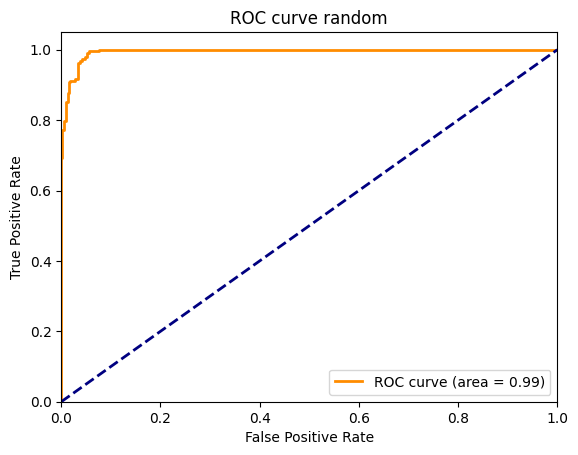

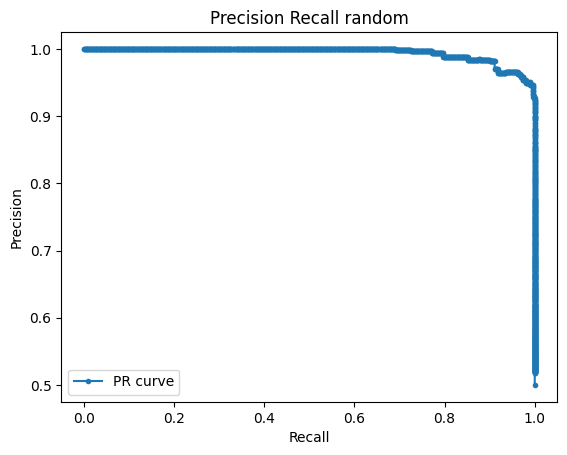

In [8]:
#plot_AUC(pred_label, true_label)
plot_AUC(PRED, true_label, "random")

#plot_PR(pred_label, true_label)
plot_PR(PRED, true_label, "random")

In [9]:
# Test Link Prediction on Real-world Network

timesteps = int(1e3)
H0 = xgi.load_xgi_data("email-enron")


H0 = m.GrowingHypergraph(H0)
longest = max(H0.edges.size.aslist())

H1 = xgi.Hypergraph()
for i in range(int(1e3)):
    
    H1.add_edge(H0.edges.members(i))
    
# Fit the model to get the esitmated parameters for email enron graph
model1 = em.EM(eslg, nhl, nnl) 
H1 = m.GrowingHypergraph(H1)
model1.fit(H1)

/storage/homes/pchodrow/HyperGraph/code/src/em.py:123: RuntimeWarning: divide by zero encountered in log
  return np.ma.masked_invalid(np.log(means)).sum()


Step 0: marginal ll = -5616.197576163002
Step 1: marginal ll = -5377.463265264223
Step 2: marginal ll = -5355.128161049723
Step 3: marginal ll = -5353.600685140164
Step 4: marginal ll = -5353.507269933675
Step 5: marginal ll = -5353.503030015536
Step 6: marginal ll = -5353.503226981049


In [10]:
eta1 = model1.pars["eta"]
beta1 = model1.pars["beta"]
gamma1 = model1.pars["gamma"]
model1.pars

{'eta': 0.7887822156010514, 'beta': 0.109, 'gamma': 0.17636341924705376}

/tmp/ipykernel_160199/3019167215.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn-whitegrid")


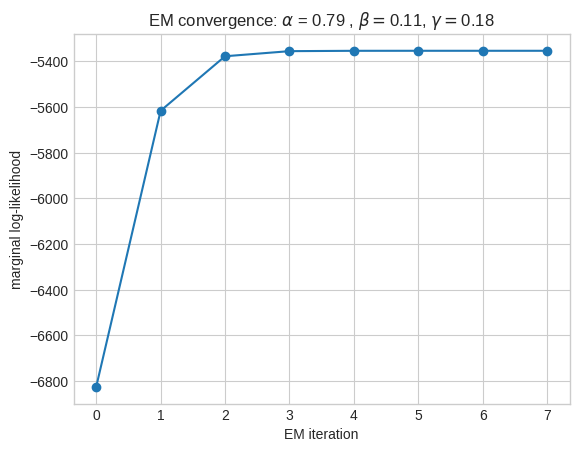

In [45]:
plt.style.use("seaborn-whitegrid")
plt.plot(model1.ll_history)
plt.scatter(np.arange(len(model1.ll_history)), model1.ll_history, zorder = 10)

labs = plt.gca().set(xlabel = "EM iteration", ylabel = "marginal log-likelihood", title = r"EM convergence: $\alpha$ = " + str(round(model1.pars["eta"], 2)) + " " + r", $\beta = $" + str(round(model1.pars["beta"], 2)) +  ", $\gamma = $" + str(round(model1.pars["gamma"], 2)))

plt.savefig("figures/em-convergence.png", dpi = 300, bbox_inches = "tight")

In [12]:
# now we build a model using the guaranteed version of the sampler 
# because that's how we built the original hypergraph
pos_edges = []
neg_edges = []

for i in range(int(1e3),int(2e3)):    
    pos_edges.append(list(H0.edges.members(i)))
    rand = random.randint(2, longest)
    neg_edges.append(random.sample(range(1, len(H1.nodes)), rand))


In [18]:
to_pred = [list(x) for x in pos_edges] + [list(x) for x in neg_edges]
true_label = [1]*int(1e3) + [0]*int(1e3)
PRED = model1.predict(to_pred)
# threshold = statistics.median(PRED)
# pred_label = copy.deepcopy(PRED)
# pred_label[pred_label>threshold] = 1
# pred_label[pred_label<=threshold] = 0

<Figure size 640x480 with 0 Axes>

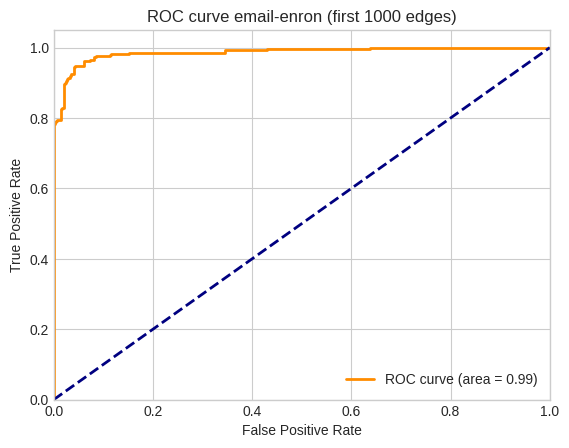

In [38]:
PRED#plot_AUC(pred_label, true_label)
plot_AUC(PRED, true_label, "email-enron")

# plt.savefig("figures/ROC_email-enron.png", dpi = 300)

#plot_PR(pred_label, true_label)
# plot_PR(PRED, true_label, "email-enron")
